In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2
import segmentation_models_pytorch as smp

/home/calebe/geo-projects-car/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# 1. Re-define the exact model architecture
model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    classes=1,
    in_channels=3,
    activation="sigmoid")

# 2. Load the state dictionary from the .pth file
# checkpoint = torch.load('experiments/excluding-jitter-and-using-256-resolution-and-256-step_20260206_142332/best_model.pth', map_location=torch.device('cuda'))

checkpoint = torch.load('experiments/excluding-jitter-and-using-256-resolution-and-256-step_20260206_142332/best_model.pth', map_location=torch.device('cpu'))
model.load_state_dict(checkpoint['model_state_dict'])

# # Check if the checkpoint contains 'model' or 'state_dict' key
# if 'model' in checkpoint:
#     model.load_state_dict(checkpoint['model'])
# elif 'state_dict' in checkpoint:
#     model.load_state_dict(checkpoint['state_dict'])
# else:
#     model.load_state_dict(checkpoint) # In case it's just the state_dict saved directly

# 3. Set to evaluation mode
model.eval()


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
      

In [3]:
image_sat_path = "/data/integracar/amostras_car_orotofoto/ES-3201803-4EB246F91D14462AACC60E101C6310C8.tif"

In [30]:
image_sat_path

'/data/integracar/amostras_car_orotofoto/ES-3201803-4EB246F91D14462AACC60E101C6310C8.tif'

In [31]:
# cv_img_bgr = cv2.imread(image_sat_path)

In [32]:
# image = cv2.imread(image_sat_path)

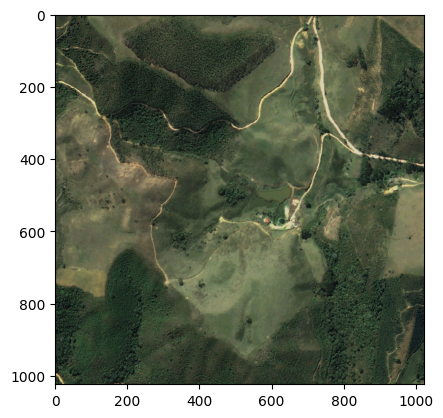

In [4]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread(image_sat_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

In [5]:
from PIL import Image
image = Image.open(image_sat_path).convert('RGB')

In [6]:
from patchify import patchify, unpatchify
image_np = np.array(image)

# Dividir em patches
image_patches = patchify(image_np, (512, 512, 3), step=512)

In [7]:
pred_patches = np.zeros((
    2, 
    2, 
    512, 
    512
), dtype=np.uint8)

In [8]:
image_patches[0,0,0]

array([[[ 63,  69,  51],
        [ 63,  69,  51],
        [ 69,  78,  51],
        ...,
        [ 74,  88,  64],
        [ 83,  88,  64],
        [ 83,  88,  64]],

       [[ 61,  72,  49],
        [ 61,  72,  49],
        [ 66,  78,  49],
        ...,
        [ 83,  88,  64],
        [ 83,  88,  64],
        [ 86,  99,  68]],

       [[ 71,  79,  61],
        [ 66,  80,  49],
        [ 72,  80,  49],
        ...,
        [ 83,  89,  64],
        [ 94,  99,  68],
        [ 96, 102,  79]],

       ...,

       [[ 83,  87,  64],
        [ 82,  88,  64],
        [ 93,  99,  79],
        ...,
        [ 27,  32,  28],
        [ 18,  28,  22],
        [ 19,  21,  23]],

       [[ 93,  99,  68],
        [ 98, 103,  79],
        [104,  99,  79],
        ...,
        [ 26,  25,  25],
        [ 19,  18,  22],
        [ 19,  15,  23]],

       [[ 93,  99,  68],
        [ 98, 103,  79],
        [104,  99,  79],
        ...,
        [ 32,  46,  43],
        [ 22,  34,  27],
        [ 29,  36,  31]]

In [9]:
from torchvision import transforms
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [25]:
model.eval()
with torch.no_grad():
    for i in range(2):
        for j in range(2):
            # Extrair patch
            patch = image_patches[i, j, 0]
            if patch.dtype != 'uint8' and patch.max() <= 1.0:
                patch = (patch * 255).astype('uint8')
            else:
                patch = patch.astype('uint8')
                
            patch_pil = Image.fromarray(patch)
            
            # Aplicar transformações
            # patch_tensor = val_transform(patch_pil)
            patch_tensor = transforms.ToTensor()(patch_pil)
            
            # Adicionar batch dimension
            patch_tensor = patch_tensor.unsqueeze(0).to('cpu')
            
            # Predição
            output = model(patch_tensor)
            probs = torch.sigmoid(output)
            pred = (probs > 0.5).float()
            pred = pred.squeeze(0).squeeze(0).cpu().numpy()

            # pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
            
            # Armazenar predição
            pred_patches[i, j] = pred

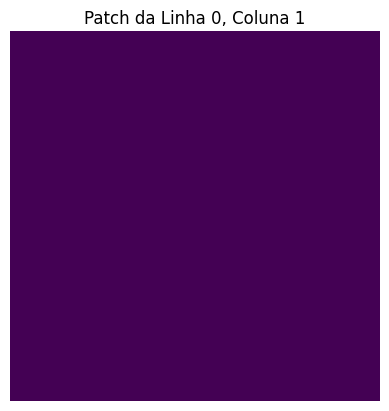

In [26]:
# single_patch = patchprees[0, 1, 0, :, :, :] 

plt.imshow(pred)
plt.title("Patch da Linha 0, Coluna 1")
plt.axis('off')
plt.show()

In [36]:
model.eval() 
patch = image_patches[1, 1, 0]
print(f"Max value no patch original: {patch.max()}")
if patch.dtype != 'uint8' and patch.max() <= 1.0:
    patch = (patch * 255).astype('uint8')
else:
    patch = patch.astype('uint8')
    
patch_pil = Image.fromarray(patch)

# Aplicar transformações
patch_tensor = val_transform(patch_pil)
# patch_tensor = transforms.ToTensor()(patch_pil)

# Adicionar batch dimension
patch_tensor = patch_tensor.unsqueeze(0).to('cpu')

# Predição
output = model(patch_tensor)
# print("Shape da saída:", output.shape) # Deve ser [1, N_CLASSES, H, W]
# print("Valores máximos por classe:", output.max(dim=3)[0].max(dim=2)[0]) 
# pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

probs = torch.sigmoid(output)
pred = (probs > 0.5).float()
pred = pred.squeeze(0).squeeze(0).cpu().numpy()

pred_patches[0, 0] = pred

Max value no patch original: 219


In [39]:
probs

tensor([[[[0.5940, 0.5659, 0.5856,  ..., 0.5993, 0.6078, 0.6297],
          [0.6116, 0.6051, 0.6373,  ..., 0.6421, 0.6398, 0.6459],
          [0.6199, 0.6320, 0.6223,  ..., 0.6604, 0.6378, 0.6354],
          ...,
          [0.6256, 0.6401, 0.6731,  ..., 0.6619, 0.6737, 0.6421],
          [0.6319, 0.6621, 0.6619,  ..., 0.6501, 0.6432, 0.6352],
          [0.6309, 0.6673, 0.6713,  ..., 0.6524, 0.6511, 0.6322]]]],
       grad_fn=<SigmoidBackward0>)

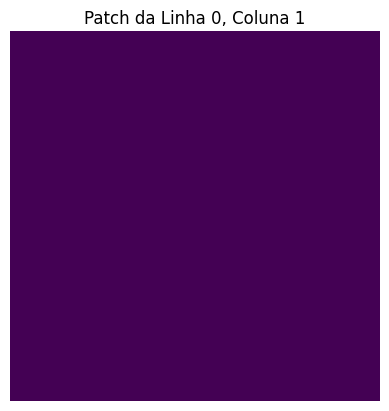

In [38]:
plt.imshow(pred)
plt.title("Patch da Linha 0, Coluna 1")
plt.axis('off')
plt.show()